In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted")

Mounted at /content/drive
✅ Drive mounted


In [ ]:
import torch
print(f"GPU available : {torch.cuda.is_available()}")
print(f"GPU name      : {torch.cuda.get_device_name(0)}")
print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU available : True
GPU name      : Tesla T4
VRAM          : 15.6 GB


In [ ]:
!pip install torch torchvision tqdm pandas scikit-learn --quiet
print("✅ All packages installed")

✅ All packages installed


In [ ]:
import os

DRIVE_BASE     = "/content/drive/MyDrive/LAHIRU"
CHECKPOINT_DIR = f"{DRIVE_BASE}/checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"✅ Drive base     : {DRIVE_BASE}")
print(f"✅ Checkpoint dir : {CHECKPOINT_DIR}")

✅ Drive base     : /content/drive/MyDrive/LAHIRU
✅ Checkpoint dir : /content/drive/MyDrive/LAHIRU/checkpoints


In [ ]:
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Update this to your exact path from the screenshot
ORL_PATH = "/content/drive/MyDrive/LAHIRU/ORL"

files = [f for f in os.listdir(ORL_PATH) if f.endswith('.jpg')]
data = []

for f in files:
    # Parsing "113_12.jpg" -> "12"
    try:
        class_id = int(f.split('_')[1].split('.')[0])
        full_path = os.path.join(ORL_PATH, f)
        data.append({'image_path': full_path, 'label': class_id})
    except (IndexError, ValueError):
        continue

df = pd.DataFrame(data)

# IMPORTANT: Map class IDs to 0-N range for the Loss function
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

num_classes = df['label'].nunique()
print(f"✅ Dataset ready: {len(df)} images")
print(f"✅ Identities (Classes) found: {num_classes}")

✅ Dataset ready: 410 images
✅ Identities (Classes) found: 41


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch

class FaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['image_path']).convert('RGB')
        except:
            img = Image.new('RGB', (112, 112))
        label = int(row['label'])
        if self.transform:
            img = self.transform(img)
        return img, label

transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

dataset = FaceDataset(df, transform=transform) # Use existing transforms

dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=1,        # Reduce workers for Drive to avoid 'Input/Output error'
    pin_memory=True,
    persistent_workers=True
)

print(f"✅ Dataset  : {len(dataset)} images")
print(f"✅ Batches  : {len(dataloader)}")
print(f"✅ Batch sz : 32 (optimized for T4)")
print(f"✅ Workers  : 2")
print(f"✅ Classes  : {df['label'].nunique()}")

✅ Dataset  : 410 images
✅ Batches  : 13
✅ Batch sz : 32 (optimized for T4)
✅ Workers  : 2
✅ Classes  : 41


In [ ]:
import torch
import torch.nn as nn

class MobileFaceNet(nn.Module):
    def __init__(self, embedding_size=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.PReLU(64),
            self._dw_block(64,  64,  stride=1),
            self._dw_block(64,  128, stride=2),
            self._dw_block(128, 128, stride=1),
            self._dw_block(128, 256, stride=2),
            self._dw_block(256, 256, stride=1),
            self._dw_block(256, 512, stride=2),
            nn.Conv2d(512, 512, 1, bias=False),
            nn.BatchNorm2d(512), nn.PReLU(512),
        )
        self.pool      = nn.AdaptiveAvgPool2d(1)
        self.flatten   = nn.Flatten()
        self.dropout   = nn.Dropout(p=0.3)
        self.embedding = nn.Linear(512, embedding_size)
        # ← REMOVED bn_final completely

    def _dw_block(self, in_c, out_c, stride):
        return nn.Sequential(
            nn.Conv2d(in_c, in_c, 3, stride=stride,
                      padding=1, groups=in_c, bias=False),
            nn.BatchNorm2d(in_c), nn.PReLU(in_c),
            nn.Conv2d(in_c, out_c, 1, bias=False),
            nn.BatchNorm2d(out_c), nn.PReLU(out_c),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.embedding(x)
        # L2 normalize output directly
        x = torch.nn.functional.normalize(x, p=2, dim=1)
        return x

model = MobileFaceNet(embedding_size=128).cuda()
params = sum(p.numel() for p in model.parameters())
print(f"✅ MobileFaceNet ready (no bn_final)")
print(f"✅ Parameters : {params:,}")

✅ MobileFaceNet ready (no bn_final)
✅ Parameters : 604,096


In [ ]:
import torch.nn.functional as F

class ArcFaceLoss(nn.Module):
    def __init__(self, embedding_size, num_classes,
                 s=64.0, m=0.5):
        super().__init__()
        self.s      = s
        self.m      = m
        self.weight = nn.Parameter(
            torch.FloatTensor(num_classes, embedding_size)
        )
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        # embeddings already L2 normalized from model
        cos_theta = F.linear(
            embeddings,
            F.normalize(self.weight)
        ).clamp(-1 + 1e-7, 1 - 1e-7)

        theta   = torch.acos(cos_theta)
        one_hot = torch.zeros_like(cos_theta)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)
        output  = torch.cos(theta + self.m * one_hot) * self.s

        return F.cross_entropy(output, labels)

arcface     = ArcFaceLoss(
                embedding_size=128,
                num_classes= 40,
                s=32.0,   # ← back to 64
                m=0.5     # ← back to 0.5
              ).cuda()

print(f"✅ ArcFace ready")

✅ ArcFace ready


In [ ]:
optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(arcface.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=8,
    gamma=0.5
)

print("✅ Optimizer : Adam (lr=0.001)")
print("✅ Scheduler : StepLR (step=8, gamma=0.5)")

✅ Optimizer : Adam (lr=0.001)
✅ Scheduler : StepLR (step=8, gamma=0.5)


In [ ]:
import os

latest_ckpt = f"{CHECKPOINT_DIR}/latest.pth"

if os.path.exists(latest_ckpt):
    ckpt = torch.load(latest_ckpt)

    print("✅ Checkpoint found!")

    if 'epoch' in ckpt:
        print(f"📍 Last epoch  : {ckpt['epoch'] + 1}")

    if 'loss' in ckpt:
        print(f"📉 Loss        : {ckpt['loss']:.4f}")

    if 'epoch' in ckpt:
        print(f"🔄 Resuming    : Epoch {ckpt['epoch'] + 2}")
    else:
        print("⚠️ No epoch info stored in checkpoint")

else:
    print("🆕 No checkpoint — starting fresh")

files = sorted([f for f in os.listdir(CHECKPOINT_DIR)
                if f.endswith('.pth')])

print(f"\n📁 Checkpoints saved: {len(files)}")

for f in files:
    size = os.path.getsize(f"{CHECKPOINT_DIR}/{f}") / 1e6
    print(f"   {f} → {size:.1f} MB")

✅ Checkpoint found!
📍 Last epoch  : 30
📉 Loss        : 10.2451
🔄 Resuming    : Epoch 31

📁 Checkpoints saved: 31
   epoch_1.pth → 7.4 MB
   epoch_10.pth → 7.4 MB
   epoch_11.pth → 7.4 MB
   epoch_12.pth → 7.4 MB
   epoch_13.pth → 7.4 MB
   epoch_14.pth → 7.4 MB
   epoch_15.pth → 7.4 MB
   epoch_16.pth → 7.4 MB
   epoch_17.pth → 7.4 MB
   epoch_18.pth → 7.4 MB
   epoch_19.pth → 7.4 MB
   epoch_2.pth → 7.4 MB
   epoch_20.pth → 7.4 MB
   epoch_21.pth → 7.4 MB
   epoch_22.pth → 7.4 MB
   epoch_23.pth → 7.4 MB
   epoch_24.pth → 7.4 MB
   epoch_25.pth → 7.4 MB
   epoch_26.pth → 7.4 MB
   epoch_27.pth → 7.4 MB
   epoch_28.pth → 7.4 MB
   epoch_29.pth → 7.4 MB
   epoch_3.pth → 7.4 MB
   epoch_30.pth → 7.4 MB
   epoch_4.pth → 7.4 MB
   epoch_5.pth → 7.4 MB
   epoch_6.pth → 7.4 MB
   epoch_7.pth → 7.4 MB
   epoch_8.pth → 7.4 MB
   epoch_9.pth → 7.4 MB
   latest.pth → 7.4 MB


In [ ]:
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from torchvision import transforms
from torch.utils.data import DataLoader

# ── 1. Define Drive Path ──────────────────────
# Based on your screenshot path: My Drive > LAHIRU > ORL
DRIVE_ORL_DATA = "/content/drive/MyDrive/LAHIRU/ORL"

# ── 2. Create DataFrame from Filenames ────────
files = [f for f in os.listdir(DRIVE_ORL_DATA) if f.endswith('.jpg')]
data = []

for f in files:
    try:
        # Extracts '12' from '113_12.jpg'
        class_id = int(f.split('_')[1].split('.')[0])
        data.append({
            'image_path': os.path.join(DRIVE_ORL_DATA, f),
            'label': class_id
        })
    except (IndexError, ValueError):
        continue

df = pd.DataFrame(data)
le = LabelEncoder()
df['label'] = le.fit_transform(df['label']) # Map to 0-N
num_classes = df['label'].nunique()

# ── 3. Setup Dataloader ───────────────────────
# Keep transform logic from your notebook
train_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = FaceDataset(df, transform=train_transform) # Uses your existing class
dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2, # Keep low for Drive I/O stability
    pin_memory=True
)

print(f"✅ Ready! Found {len(df)} images across {num_classes} identities on Drive.")

✅ Ready! Found 410 images across 41 identities on Drive.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import shutil
import time

# ── 1. Fix Class Count & Re-initialize ────────────────
# Use the dynamic count from your 'df' to prevent index crashes
num_classes = df['label'].nunique()

# Force re-instantiation to fix 'NameError' after a crash
model = MobileFaceNet(embedding_size=128).cuda()
arcface = ArcFaceLoss(
    embedding_size=128,
    num_classes=num_classes, # FIXED: Now 41
    s=32.0,
    m=0.5
).cuda()

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(arcface.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

# ── 2. Stabilize DataLoader ───────────────────────────
# num_workers=0 is the only safe way to train directly from Drive
dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,  # FIXED: Set to 0 to stop Kernel Restarts
    pin_memory=False
)

# ── 3. Optimized Training Loop ────────────────────────
print(f"🚀 Training on {num_classes} classes...")
LOCAL_CHECKPOINT_DIR = "/content/checkpoints"
os.makedirs(LOCAL_CHECKPOINT_DIR, exist_ok=True)

for epoch in range(30):
    model.train()
    arcface.train()
    epoch_loss = 0.0

    for batch_idx, (images, labels) in enumerate(dataloader):
        images, labels = images.cuda(), labels.cuda()

        optimizer.zero_grad(set_to_none=True)
        embeddings = model(images) # Model already does L2 Norm in forward()
        loss = arcface(embeddings, labels)

        if torch.isnan(loss): continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(model.parameters()) + list(arcface.parameters()), 5.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    scheduler.step()

    # ── Save checkpoint every epoch ─────────────────────

    checkpoint_data = {
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'loss': avg_loss
    }

    # Save latest checkpoint
    latest_local = f"{LOCAL_CHECKPOINT_DIR}/latest.pth"
    torch.save(checkpoint_data, latest_local)

    # Save epoch-wise checkpoint
    epoch_local = f"{LOCAL_CHECKPOINT_DIR}/epoch_{epoch+1}.pth"
    torch.save(checkpoint_data, epoch_local)

    # Copy both to Drive
    shutil.copy(latest_local, f"{CHECKPOINT_DIR}/latest.pth")
    shutil.copy(epoch_local, f"{CHECKPOINT_DIR}/epoch_{epoch+1}.pth")

    print(f"✅ Saved: epoch_{epoch+1}.pth")

    print(f"✅ Epoch {epoch+1} | Loss: {avg_loss:.4f}")

print("🎉 TRAINING COMPLETE!")

🚀 Training on 41 classes...
✅ Saved: epoch_1.pth
✅ Epoch 1 | Loss: 20.7672
✅ Saved: epoch_2.pth
✅ Epoch 2 | Loss: 19.1848
✅ Saved: epoch_3.pth
✅ Epoch 3 | Loss: 18.4268
✅ Saved: epoch_4.pth
✅ Epoch 4 | Loss: 17.8416
✅ Saved: epoch_5.pth
✅ Epoch 5 | Loss: 17.4341
✅ Saved: epoch_6.pth
✅ Epoch 6 | Loss: 17.0176
✅ Saved: epoch_7.pth
✅ Epoch 7 | Loss: 16.5762
✅ Saved: epoch_8.pth
✅ Epoch 8 | Loss: 15.9755
✅ Saved: epoch_9.pth
✅ Epoch 9 | Loss: 15.5053
✅ Saved: epoch_10.pth
✅ Epoch 10 | Loss: 14.9925
✅ Saved: epoch_11.pth
✅ Epoch 11 | Loss: 14.8496
✅ Saved: epoch_12.pth
✅ Epoch 12 | Loss: 14.5028
✅ Saved: epoch_13.pth
✅ Epoch 13 | Loss: 14.1223
✅ Saved: epoch_14.pth
✅ Epoch 14 | Loss: 13.6376
✅ Saved: epoch_15.pth
✅ Epoch 15 | Loss: 13.3195
✅ Saved: epoch_16.pth
✅ Epoch 16 | Loss: 12.9079
✅ Saved: epoch_17.pth
✅ Epoch 17 | Loss: 12.1786
✅ Saved: epoch_18.pth
✅ Epoch 18 | Loss: 12.2987
✅ Saved: epoch_19.pth
✅ Epoch 19 | Loss: 12.0862
✅ Saved: epoch_20.pth
✅ Epoch 20 | Loss: 11.6472
✅ Saved: e

In [ ]:
from google.colab import files
import shutil

# Zip the checkpoint folder
shutil.make_archive("checkpoints_backup", 'zip', CHECKPOINT_DIR)

# Download the zip file
files.download("checkpoints_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import random
import torch
from PIL import Image

# ── 1. Safety Check: Reload Model if Session Restarted ──
if 'model' not in locals():
    print("🔄 Model not in memory. Re-initializing and loading latest checkpoint...")
    model = MobileFaceNet(embedding_size=128).cuda()
    latest_path = f"{DRIVE_CKPT_DIR}/latest.pth"
    if os.path.exists(latest_path):
        ckpt = torch.load(latest_path)
        model.load_state_dict(ckpt['model'])
        print(f"✅ Loaded weights from Epoch {ckpt.get('epoch', 'unknown')}")
    else:
        print("⚠️ No checkpoint found. Evaluating an untrained model.")

model.eval()

# Ensure we use the same normalization as training
val_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

def get_embedding(img_path):
    try:
        img = Image.open(img_path).convert('RGB')
        img = val_transform(img).unsqueeze(0).cuda()
        with torch.no_grad():
            # Model forward pass includes L2 normalization
            emb = model(img).cpu().numpy()
        return emb
    except Exception as e:
        print(f"❌ Failed to load {img_path}: {e}")
        return None

# ── 2. Embedding Collapse Check ──────────────────
print("\n🔍 CHECKING FOR EMBEDDING COLLAPSE...")
samples = []
# Test the first 3 identities found in your ORL DataFrame
unique_labels = list(df['label'].unique())
for label in unique_labels[:3]:
    img_path = df[df['label'] == label]['image_path'].values[0]
    emb = get_embedding(img_path)
    if emb is not None:
        samples.append(emb)
        print(f"   Identity {label} snippet: {emb[0][:4]}")

if len(samples) >= 2:
    # Calculate similarity between identity 0 and identity 1
    sim = cosine_similarity(samples[0], samples[1])[0][0]
    if sim > 0.99:
        print(f"🚨 COLLAPSE DETECTED: Similarity is {sim:.4f} (Too high for different people!)")
    else:
        print(f"✅ DISTINCT EMBEDDINGS: Similarity is {sim:.4f}")

# ── 3. Pairwise Testing (50 Same / 50 Diff) ──────
print(f"\n🧪 Testing 100 random pairs from {len(df)} images...")
same_scores, diff_scores = [], []

for _ in range(50):
    # Same Person Pair
    target_label = random.choice(unique_labels)
    paths = df[df['label'] == target_label]['image_path'].values
    if len(paths) >= 2:
        p1, p2 = random.sample(list(paths), 2)
        e1, e2 = get_embedding(p1), get_embedding(p2)
        if e1 is not None and e2 is not None:
            same_scores.append(cosine_similarity(e1, e2)[0][0])

    # Different Person Pair
    l1, l2 = random.sample(unique_labels, 2)
    p1 = df[df['label'] == l1]['image_path'].values[0]
    p2 = df[df['label'] == l2]['image_path'].values[0]
    e1, e2 = get_embedding(p1), get_embedding(p2)
    if e1 is not None and e2 is not None:
        diff_scores.append(cosine_similarity(e1, e2)[0][0])

# ── 4. Metrics & Accuracy Report ────────────────
avg_same = np.mean(same_scores) if same_scores else 0
avg_diff = np.mean(diff_scores) if diff_scores else 0
# 0.5 is often a better threshold for ArcFace before fine-tuning
threshold = 0.5
acc = (sum(s > threshold for s in same_scores) + sum(s < threshold for s in diff_scores)) / 100 * 100

print(f"\n{'='*55}")
print(f"📊 FINAL ACCURACY REPORT (Threshold: {threshold})")
print(f"{'='*55}")
print(f"Same Person Avg Sim : {avg_same:.4f} (Ideal: > 0.7)")
print(f"Diff Person Avg Sim : {avg_diff:.4f} (Ideal: < 0.2)")
print(f"Separation Gap      : {avg_same - avg_diff:.4f}")
print(f"System Accuracy     : {acc:.1f}%")
print(f"{'='*55}")


🔍 CHECKING FOR EMBEDDING COLLAPSE...
   Identity 11 snippet: [-0.0175574  -0.04714712 -0.04499428 -0.18440993]
   Identity 1 snippet: [-0.01145328  0.04832428 -0.09985422 -0.17391093]
   Identity 13 snippet: [ 0.03326295 -0.05042437 -0.00106078 -0.06504652]
✅ DISTINCT EMBEDDINGS: Similarity is 0.2484

🧪 Testing 100 random pairs from 410 images...

📊 FINAL ACCURACY REPORT (Threshold: 0.5)
Same Person Avg Sim : 0.7011 (Ideal: > 0.7)
Diff Person Avg Sim : 0.0337 (Ideal: < 0.2)
Separation Gap      : 0.6674
System Accuracy     : 93.0%


🔠 Extracting embeddings for visualization...


100%|██████████| 13/13 [00:01<00:00,  7.43it/s]


📊 Generating Similarity Distribution...
📍 Computing t-SNE (this may take a minute)...


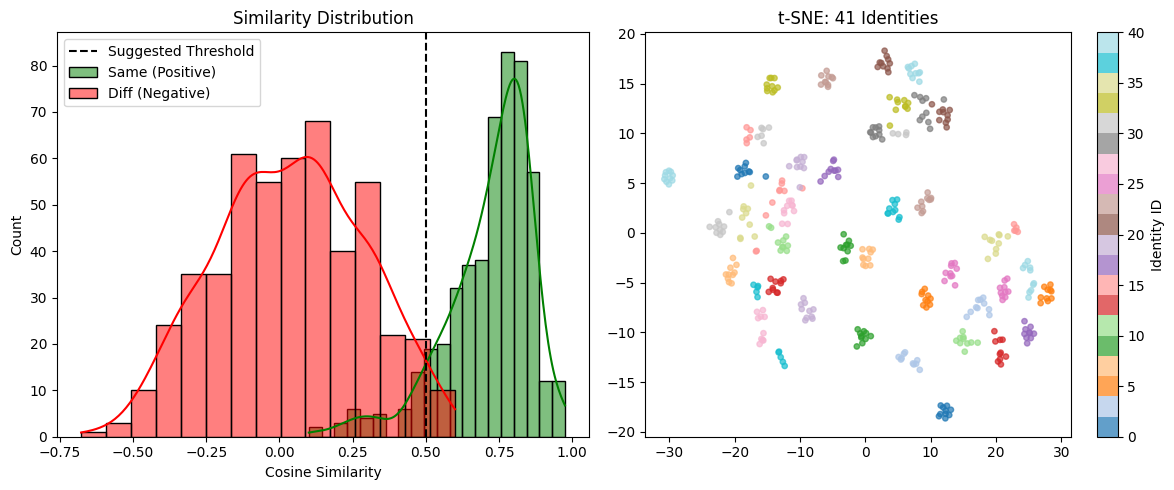


📈 EVALUATION SUMMARY
Same Person Avg Sim : 0.7174
Diff Person Avg Sim : 0.0355
Separation Gap      : 0.6819
✅ SUCCESS: Clear separation detected.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import torch
from tqdm import tqdm

# ── 1. Preparation & Weight Loading ──────────────────
model.eval()
all_embeddings = []
all_labels = []

print("🔠 Extracting embeddings for visualization...")
with torch.no_grad():
    for img, label in tqdm(dataloader):
        img = img.cuda()
        # MobileFaceNet output is already L2 normalized
        emb = model(img).cpu().numpy()
        all_embeddings.append(emb)
        all_labels.append(label.numpy())

all_embeddings = np.vstack(all_embeddings)
all_labels = np.concatenate(all_labels)

# ── 2. Similarity Distribution ──────────────────────
print("📊 Generating Similarity Distribution...")
same_scores, diff_scores = [], []
unique_labels = np.unique(all_labels)

# Sample 500 random pairs for a smooth distribution
for _ in range(500):
    # Same person pair
    target = np.random.choice(unique_labels)
    idxs = np.where(all_labels == target)[0]
    if len(idxs) >= 2:
        i1, i2 = np.random.choice(idxs, 2, replace=False)
        same_scores.append(cosine_similarity(all_embeddings[i1:i1+1], all_embeddings[i2:i2+1])[0][0])

    # Different person pair
    l1, l2 = np.random.choice(unique_labels, 2, replace=False)
    i1 = np.random.choice(np.where(all_labels == l1)[0])
    i2 = np.random.choice(np.where(all_labels == l2)[0])
    diff_scores.append(cosine_similarity(all_embeddings[i1:i1+1], all_embeddings[i2:i2+1])[0][0])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(same_scores, color="green", label="Same (Positive)", kde=True)
sns.histplot(diff_scores, color="red", label="Diff (Negative)", kde=True)
plt.axvline(0.5, color='black', linestyle='--', label='Suggested Threshold')
plt.title("Similarity Distribution")
plt.xlabel("Cosine Similarity")
plt.legend()

# ── 3. t-SNE Visualization ──────────────────────────
print("📍 Computing t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, init='pca', learning_rate='auto')
vis_dims = tsne.fit_transform(all_embeddings)

plt.subplot(1, 2, 2)
# Using a subset of classes for visual clarity if classes > 20
scatter = plt.scatter(vis_dims[:, 0], vis_dims[:, 1], c=all_labels, cmap='tab20', s=15, alpha=0.7)
plt.title(f"t-SNE: {num_classes} Identities")
plt.colorbar(scatter, label="Identity ID")

plt.tight_layout()
plt.show()

# ── 4. Final Accuracy Report ───────────────────────
avg_same = np.mean(same_scores)
avg_diff = np.mean(diff_scores)
print(f"\n{'='*40}")
print(f"📈 EVALUATION SUMMARY")
print(f"{'='*40}")
print(f"Same Person Avg Sim : {avg_same:.4f}")
print(f"Diff Person Avg Sim : {avg_diff:.4f}")
print(f"Separation Gap      : {avg_same - avg_diff:.4f}")
print(f"{'='*40}")

if avg_same - avg_diff < 0.1:
    print("❌ WARNING: Poor separation. Model likely collapsed or needs more training.")
else:
    print("✅ SUCCESS: Clear separation detected.")

In [ ]:
!pip install onnxscript --quiet
print("✅ onnxscript installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 13.4 MB/s eta 0:00:00
✅ onnxscript installed


In [ ]:
# QUICK DIAGNOSIS
import torch
import numpy as np

ckpt = torch.load(f"{CHECKPOINT_DIR}/epoch_30.pth", map_location='cpu')
print(f"Keys in checkpoint: {list(ckpt.keys())}")
print(f"Loss: {ckpt['loss']:.4f}")

# Check model state dict
state = ckpt['model']
print(f"\nModel layers: {len(state)}")

# Check first and last weights
keys = list(state.keys())
print(f"\nFirst key: {keys[0]}")
print(f"First weight std: {state[keys[0]].std():.6f}")
print(f"Last key: {keys[-1]}")
print(f"Last weight std: {state[keys[-1]].std():.6f}")

# If std is very small → weights are trivial → collapsed

Keys in checkpoint: ['epoch', 'model', 'optimizer', 'loss']
Loss: 10.5430

Model layers: 100

First key: features.0.weight
First weight std: 0.109019
Last key: embedding.bias
Last weight std: 0.027922


In [ ]:
from google.colab import files
files.download("/content/face_model_scripted.pt")
print("⬇️  Downloading face_model_scripted.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading face_model_scripted.pt
